In [3]:
import pandas as pd

file = r"C:\Users\ronit\Downloads\UK Cost Of Living Project\Data\Raw\Consumer price inflation tables\2026.xlsx"

excel_file = pd.ExcelFile(file)

print(excel_file.sheet_names)

df = pd.read_excel(file, sheet_name="Table 1")


table6 = pd.read_excel(
    file,
    sheet_name="Table 6a, 6b, 6c",
    header=None
)

print(table6.head(15))


['Contents', 'Table 1', 'Table 2', 'Table 3', 'Table 4', 'Table 5a, 5b', 'Table 6a, 6b, 6c', 'Table 7', 'Table 8', 'Table 9', 'Table 10', 'Table 11', 'Table 12', 'Table 13', 'Table 14', 'Table 15a, 15b, 15c', 'Table 16', 'Table 17', 'Table 18', 'Table 19', 'Table 20', 'Table 21', 'Table 22', 'Table 23', 'Table 24', 'Table 25', 'Table 26', 'Table 27', 'Table 28', 'Table 29', 'Table 30', 'Table 31a, 31b', 'Table 32', 'Table 33', 'Table 34', 'Table 35', 'Table 36a, 36b', 'Table 37', 'Table 38', 'Table 39', 'Table 40']
                  0                                     1         2     3   \
0   Back to Contents                                   NaN       NaN   NaN   
1                NaN                                   NaN       NaN   NaN   
2           Table 6a   CPIH All Items: 2005 to 2026  1,2,3       NaN   NaN   
3                NaN                                   NaN       NaN   NaN   
4                NaN                                   NaN    Annual         
5          

In [4]:
cpi = table6.iloc[7:29, [1,2]].copy()

cpi.columns = ["Year", "CPIH"]
cpi = cpi[cpi["Year"] >= 2015]
cpi["Year"] = pd.to_numeric(cpi["Year"])
cpi.info
cpi["CPIH"] = pd.to_numeric(cpi["CPIH"], errors = "coerce")
cpi.isna().sum()
cpi_2015 = cpi.loc[cpi["Year"] == 2015, "CPIH"].iloc[0]
cpi_2025 = cpi.loc[cpi["Year"] == 2025, "CPIH"].iloc[0]

cumulative_inflation = ((cpi_2025/cpi_2015) - 1) * 100
cpi["Inflation"] = cpi["CPIH"].pct_change()*100
cpi["Inflation"] = cpi["Inflation"].round(2)
print(cumulative_inflation)
cpi

37.999999999999986


,Year,CPIH,Inflation
17,2015,100.0,NaN
18,2016,101.0,1.00
19,2017,103.6,2.57
20,2018,106.0,2.32
21,2019,107.8,1.70
22,2020,108.9,1.02
23,2021,111.6,2.48
24,2022,120.5,7.97
25,2023,128.6,6.72
26,2024,132.9,3.34


In [5]:
import matplotlib.pyplot as plt

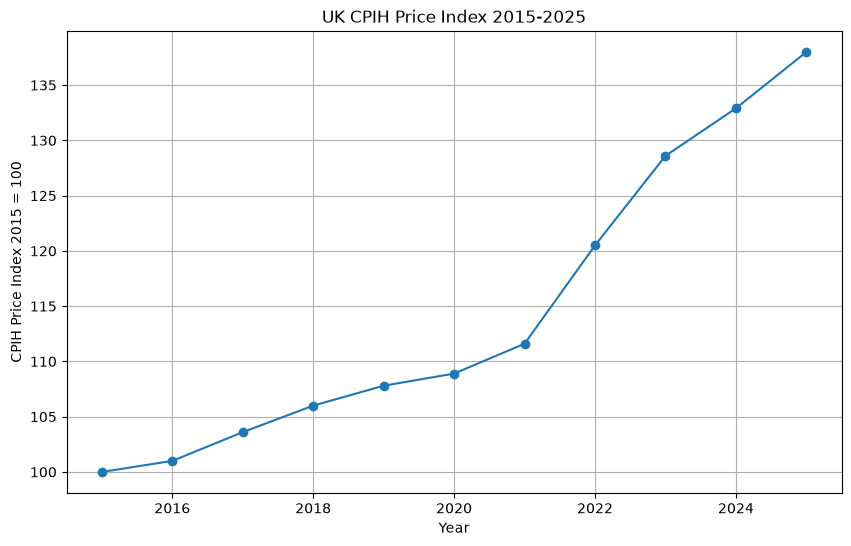

In [6]:
plt.figure(figsize=(10,6))
plt.plot(
    cpi["Year"],
    cpi["CPIH"],
    marker="o"
)
plt.title("UK CPIH Price Index 2015-2025")
plt.xlabel("Year")
plt.ylabel("CPIH Price Index 2015 = 100")
plt.grid(True)
plt.show()

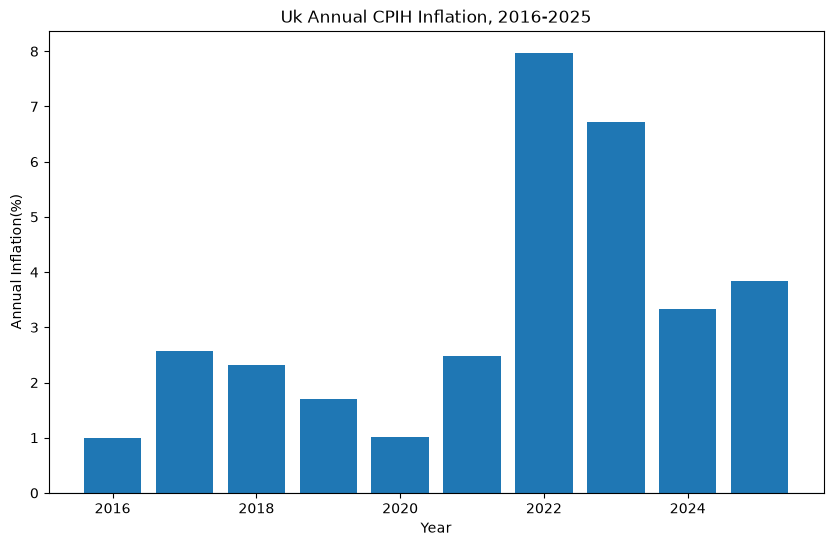

In [7]:
plt.figure(figsize=(10,6))
plt.bar(
    cpi["Year"],
    cpi["Inflation"]
)
plt.title("Uk Annual CPIH Inflation, 2016-2025")
plt.xlabel("Year")
plt.ylabel("Annual Inflation(%)")
plt.axhline(0,linewidth=0.8)
plt.show()

In [8]:
cpi["Cumulative_change"] = (
    (cpi["CPIH"] / 100) - 1
) * 100
cpi

,Year,CPIH,Inflation,Cumulative_change
17,2015,100.0,NaN,0.0
18,2016,101.0,1.00,1.0
19,2017,103.6,2.57,3.6
20,2018,106.0,2.32,6.0
21,2019,107.8,1.70,7.8
22,2020,108.9,1.02,8.9
23,2021,111.6,2.48,11.6
24,2022,120.5,7.97,20.5
25,2023,128.6,6.72,28.6
26,2024,132.9,3.34,32.9


In [9]:
cpi.to_csv("clean_cpi.csv", index=False)
